In [1]:
import numpy as np 
from scipy.stats import multinomial 
import matplotlib.pyplot as plt  
from scipy.optimize import differential_evolution, Bounds
from scipy.stats import spearmanr

np.random.seed(123457)

In [2]:
def generate_mentions(z, n):
    """ Generate n mentions given a ideological position z """
    # Partition function
    Z = lambda x: np.exp(x) + 1 + np.exp(-x)
    # Probabilities of output -1, 0, or 1 
    probabilities = np.array([np.exp(-z), 1, np.exp(z)]) / Z(z)

    # Realization of the probabilistic process
    mentions_realization = multinomial.rvs(n = n, p=probabilities)

    return mentions_realization

### Artificial data

In [3]:
n_media_outlets = 20
n_subjects = 3

z_media_outlets = np.linspace(-2, 2, n_media_outlets)
print('z media outlets:', z_media_outlets)

a_subjects = np.linspace(-1, 1, n_subjects)
print('a subjects:', a_subjects)

b_subjects = np.random.normal(loc = 0.00, scale = 0.05, size = n_subjects)
print('b subjects:', b_subjects)

z media outlets: [-2.         -1.78947368 -1.57894737 -1.36842105 -1.15789474 -0.94736842
 -0.73684211 -0.52631579 -0.31578947 -0.10526316  0.10526316  0.31578947
  0.52631579  0.73684211  0.94736842  1.15789474  1.36842105  1.57894737
  1.78947368  2.        ]
a subjects: [-1.  0.  1.]
b subjects: [-0.01372063 -0.0018417   0.09535376]


Data matrix:

In [4]:
mentions_matrix = np.zeros(shape = [n_media_outlets, n_subjects, 3])

In [5]:
# Mean of total mentions 
mean_N = 100

for i in range(n_media_outlets):
    for j in range(n_subjects):
        # ideology
        z_ij = z_media_outlets[i] * a_subjects[j] + b_subjects[j]
        N_ij = np.random.poisson(mean_N)
        mentions_ij = generate_mentions(z_ij, N_ij)
        for k in range(3):
            mentions_matrix[i][j][k] = mentions_ij[k]

In [6]:
print('Example first media outlets mentions of the first subject:', mentions_matrix[0][0])

Example first media outlets mentions of the first subject: [ 1.  9. 79.]


### Inference of data

In [7]:
def log_likelihood(x, mentions_matrix):

    """ Function to maximize """

    n_rows = mentions_matrix.shape[0]
    n_cols = mentions_matrix.shape[1]

    z, a, b = x[:n_rows], x[n_rows:(n_rows + n_cols)], x[(n_rows + n_cols):]
    
    logl = 0.00
    for i in range(n_rows):
        for j in range(n_cols):
            z_ij = z[i] * a[j] + b[j]
            N_ij = np.sum(mentions_matrix[i][j])
            logl += (mentions_matrix[i][j][2] - mentions_matrix[i][j][0]) * z_ij - N_ij * (np.log(np.exp(z_ij) + 1 + np.exp(-z_ij)))        
            logl -= 0.5*(z[i]**2 + a[j]**2 + b[j]**2)
    
    return logl

# Auxiliar function to minimize 
negative_log_likelihood = lambda x, mentions_matrix: -log_likelihood(x, mentions_matrix)

Optimizer:

In [8]:
# Bounds
lb = [-5] * (n_media_outlets + 2 * n_subjects)
ub = [5] * (n_media_outlets + 2 * n_subjects)
bounds = Bounds(lb, ub)

solution = differential_evolution(negative_log_likelihood, args=(mentions_matrix,), bounds=bounds, maxiter=1000, popsize=25)
print(solution)

             message: Optimization terminated successfully.
             success: True
                 fun: 5662.362843758067
                   x: [ 1.547e+00  1.375e+00 ...  6.544e-03  3.864e-02]
                 nit: 40
                nfev: 27973
          population: [[ 4.341e+00  3.046e+00 ... -1.789e-03  2.759e-01]
                       [ 2.657e+00  2.286e+00 ...  8.465e-02  1.011e-01]
                       ...
                       [ 2.156e+00  3.743e+00 ... -7.438e-02  4.268e-01]
                       [ 4.161e+00  2.456e+00 ...  1.614e-02  2.063e-01]]
 population_energies: [ 5.662e+03  5.939e+03 ...  5.995e+03  5.918e+03]
                 jac: [ 7.822e-03  1.910e-03 ...  2.008e-01  8.904e-02]


In [9]:
z_predicted, a_predicted, b_predicted = solution.x[:n_media_outlets], solution.x[n_media_outlets:(n_media_outlets + n_subjects)], solution.x[(n_media_outlets + n_subjects):]

Comparison of predicted and expected values:

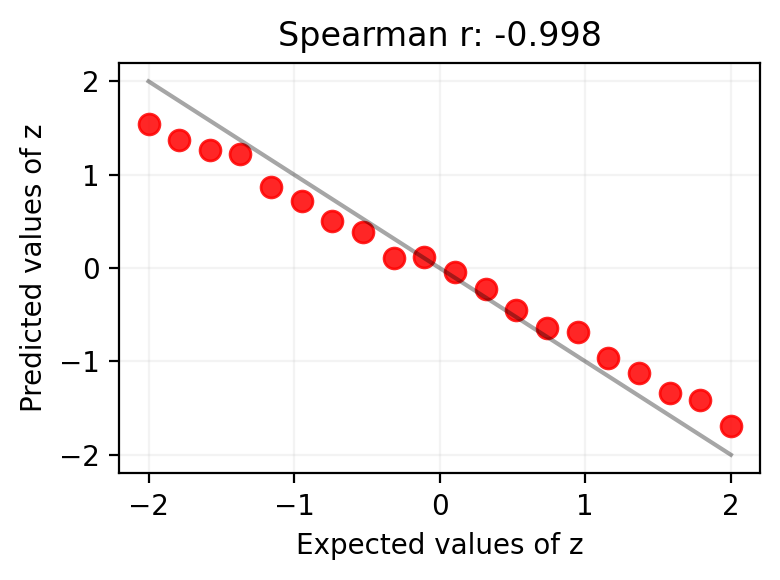

In [10]:
plt.figure(figsize = (4,3), dpi = 200)
plt.plot(z_media_outlets, z_predicted, '.', markersize = 15, alpha = 0.85, color = 'r')
if spearmanr(z_media_outlets, z_predicted).statistic > 0:
    plt.plot([-2, 2], [-2, 2], color = 'k', alpha = 0.35)
else:
    plt.plot([-2, 2], [2, -2], color = 'k', alpha = 0.35)
plt.title('Spearman r: {:.3f}'.format(spearmanr(z_media_outlets, z_predicted).statistic))
plt.xlabel(r'Expected values of z', size = 10)
plt.ylabel(r'Predicted values of z', size = 10)
plt.grid(True, alpha = 0.15)
plt.tight_layout()
plt.show()

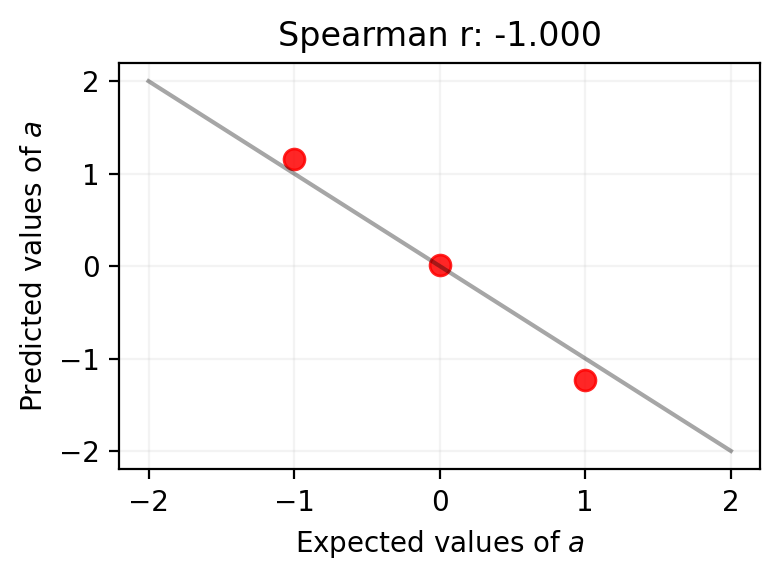

In [11]:
plt.figure(figsize = (4,3), dpi = 200)
plt.plot(a_subjects, a_predicted, '.', markersize = 15, alpha = 0.85, color = 'r')
if spearmanr(a_subjects, a_predicted).statistic > 0:
    plt.plot([-2, 2], [-2, 2], color = 'k', alpha = 0.35)
else:
    plt.plot([-2, 2], [2, -2], color = 'k', alpha = 0.35)
plt.title('Spearman r: {:.3f}'.format(spearmanr(a_subjects, a_predicted).statistic))
plt.xlabel(r'Expected values of $a$', size = 10)
plt.ylabel(r'Predicted values of $a$', size = 10)
plt.grid(True, alpha = 0.15)
plt.tight_layout()
plt.show()

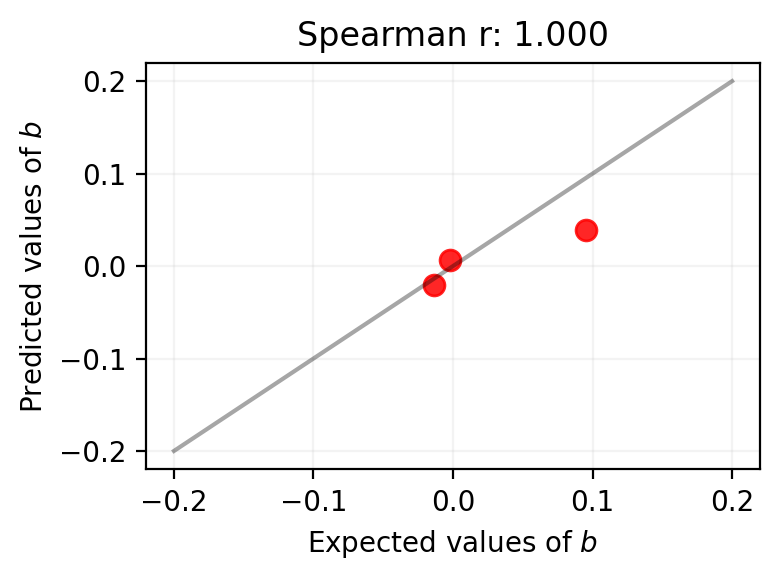

In [12]:
plt.figure(figsize = (4,3), dpi = 200)
plt.plot(b_subjects, b_predicted, '.', markersize = 15, alpha = 0.85, color = 'r')
if spearmanr(b_subjects, b_predicted).statistic > 0:
    plt.plot([-0.2, 0.2], [-0.2, 0.2], color = 'k', alpha = 0.35)
else:
    plt.plot([-0.2, 0.2], [0.2, -0.2], color = 'k', alpha = 0.35)
plt.title('Spearman r: {:.3f}'.format(spearmanr(b_subjects, b_predicted).statistic))
plt.xlabel(r'Expected values of $b$', size = 10)
plt.ylabel(r'Predicted values of $b$', size = 10)
plt.grid(True, alpha = 0.15)
plt.tight_layout()
plt.show()

In [13]:
zs_expected = []
zs_predicted = []
for i in range(n_media_outlets):
    for j in range(n_subjects):
        zs_expected.append(z_media_outlets[i] * a_subjects[j] + b_subjects[j])
        zs_predicted.append(z_predicted[i] * a_predicted[j] + b_predicted[j])

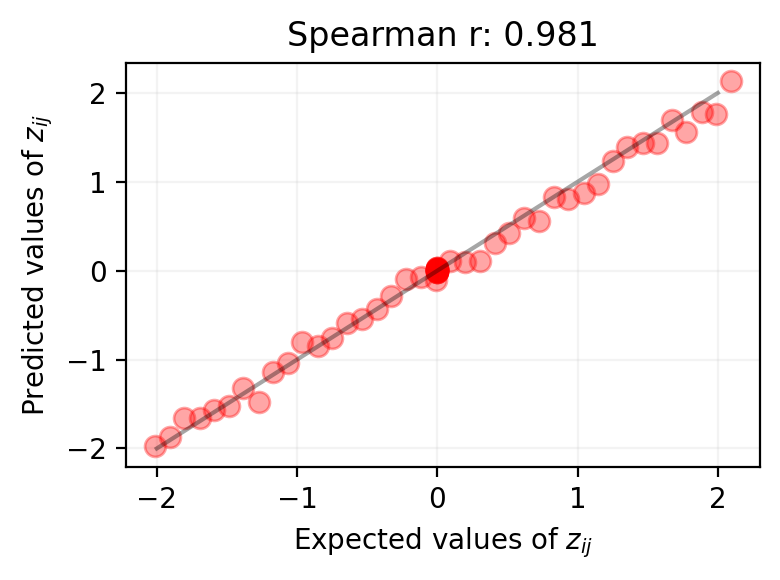

In [14]:
plt.figure(figsize = (4,3), dpi = 200)
plt.plot(zs_expected, zs_predicted, '.', markersize = 15, alpha = 0.35, color = 'r')
plt.title('Spearman r: {:.3f}'.format(spearmanr(zs_expected, zs_predicted).statistic))
plt.plot([-2, 2], [-2, 2], color = 'k', alpha = 0.35)
plt.xlabel(r'Expected values of $z_{ij}$', size = 10)
plt.ylabel(r'Predicted values of $z_{ij}$', size = 10)
plt.grid(True, alpha = 0.15)
plt.tight_layout()
plt.savefig('Predicted_z_ij.pdf')
plt.show()